In [1]:
# =============
# CARGA DE LIBRERIAS

import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import random
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [2]:
# =============
# CARGA DE DATASETS

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        # Cargamos el diccionario previamente guardado (.pt)
        data = torch.load(dataset_path)
        self.flux = data["flux"]              # Tensor con forma [N, num_points]
        self.wavelength = data["wavelength"]  # Tensor con forma [N, num_points]
        self.redshift = data["redshift"]      # Tensor con forma [N]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Rutas a los archivos preprocesados
data_dir = "data"
train_dataset_path = os.path.join(data_dir, "train_dataset_600k.pt")
test_dataset_path  = os.path.join(data_dir, "test_dataset_600k.pt")

# Crear los datasets
train_dataset = SpectraDataset(train_dataset_path)
test_dataset  = SpectraDataset(test_dataset_path)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [3]:
# =============
# DEFINICIÓN Y CONFIGURACIÓN DEL MODELO

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
        super(Transformer, self).__init__()
        self.embedding = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2)
        )
        reduced_len = num_points // 16
        self.positional_encoding = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        out = self.fc_layers(x)
        return out

# Instanciar el modelo y moverlo a GPU si está disponible
num_points = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelTransformer = Transformer(num_points).to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(modelTransformer.parameters(), lr=0.00001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

print("Modelo Transformer configurado correctamente.")

Usando dispositivo: cuda
Modelo Transformer configurado correctamente.


In [ ]:
# =============
# INICIALIZACIÓN DEL MODELO

# Cargar checkpoint y estados del modelo, optimizador y scheduler
model_path = 'storage/modelTRA_Stars.pth'
if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device)
    modelTransformer.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
else:
    start_epoch = 0
    best_val_loss = float('inf')
    print("No hay checkpoint previo. Entrenamiento desde cero.")
    
# Definir el número total de epochs que deseas entrenar
num_epochs = 100
best_val_loss = float('inf')  # Para guardar el checkpoint en caso de mejora

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs):
    modelTransformer.train()
    running_loss = 0.0
    
    # Bucle de entrenamiento con barra de progreso
    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Entrenamiento"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelTransformer(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelTransformer.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validación"):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelTransformer(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6}, Val Loss: {val_loss:.6}, LR: {current_lr:.10f}")
    
    # Guardar el checkpoint si hay mejora en la pérdida de validación
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': modelTransformer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }
        torch.save(checkpoint, 'storage/modelTRA_Stars.pth')
        print("Checkpoint guardado con éxito.")

# Evaluación final en el conjunto de prueba utilizando MAE
modelTransformer.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelTransformer(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.6}")

Epoch 11/15 - Validación: 100%|██████████| 1250/1250 [00:13<00:00, 91.19it/s]


Epoch 11/15, Loss: 0.000159838, Val Loss: 0.000158403, LR: 0.0000100000
Checkpoint guardado con éxito.


Epoch 12/15 - Validación: 100%|██████████| 1250/1250 [00:14<00:00, 84.68it/s]


Epoch 12/15, Loss: 0.000159064, Val Loss: 0.000159133, LR: 0.0000100000


Epoch 13/15 - Validación: 100%|██████████| 1250/1250 [00:13<00:00, 92.72it/s]


Epoch 13/15, Loss: 0.00015908, Val Loss: 0.000161605, LR: 0.0000100000


Epoch 14/15 - Validación: 100%|██████████| 1250/1250 [00:14<00:00, 87.18it/s]


Epoch 14/15, Loss: 0.000159452, Val Loss: 0.000164942, LR: 0.0000100000


Epoch 15/15 - Validación: 100%|██████████| 1250/1250 [00:14<00:00, 86.36it/s]


Epoch 15/15, Loss: 0.000159835, Val Loss: 0.00015812, LR: 0.0000100000
Checkpoint guardado con éxito.
Error absoluto medio en el conjunto de prueba: 0.00015812


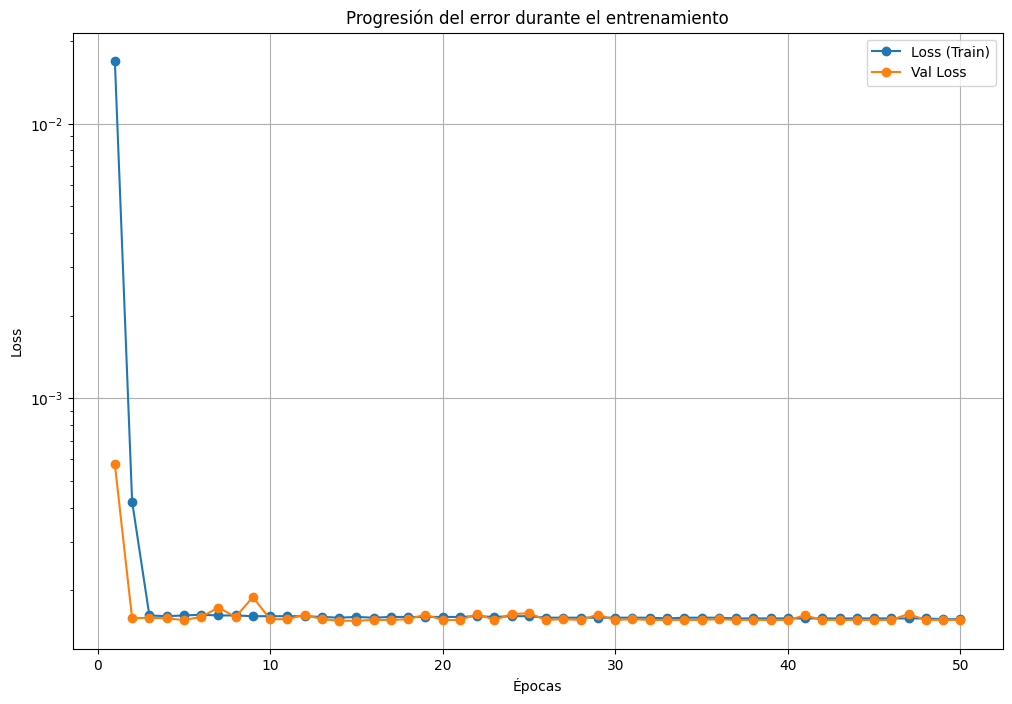

In [5]:
import matplotlib.pyplot as plt

epochs = list(range(1, 51))

# Datos extraídos de los logs
loss = [
  0.016941, 0.000421, 0.000162, 0.000161, 0.000162,
  0.000163, 0.000162, 0.000162, 0.000161, 0.000161,
  0.000161, 0.000161, 0.000160, 0.000159, 0.000160,
  0.000159, 0.000160, 0.000160, 0.000160, 0.000160,
  0.000160, 0.000161, 0.000160, 0.000161, 0.000161,
  0.000159, 0.000159, 0.000159, 0.000159, 0.000159,
  0.000159, 0.000159, 0.000158, 0.000159, 0.000159,
  0.000159, 0.000158, 0.000158, 0.000158, 0.000158,
  0.000158, 0.000158, 0.000158, 0.000158, 0.000158,
  0.000158, 0.000158, 0.000158, 0.000157, 0.000157
]

val_loss = [
  0.000575, 0.000158, 0.000159, 0.000158, 0.000156,
  0.000160, 0.000173, 0.000160, 0.000189, 0.000157,
  0.000157, 0.000163, 0.000157, 0.000155, 0.000155,
  0.000156, 0.000156, 0.000157, 0.000163, 0.000156,
  0.000156, 0.000164, 0.000156, 0.000164, 0.000165,
  0.000156, 0.000157, 0.000156, 0.000163, 0.000156,
  0.000157, 0.000156, 0.000156, 0.000156, 0.000156,
  0.000157, 0.000156, 0.000156, 0.000156, 0.000156,
  0.000162, 0.000156, 0.000156, 0.000156, 0.000156,
  0.000156, 0.000164, 0.000156, 0.000156, 0.000156
]

# Creación de la gráfica
plt.figure(figsize=(12, 8))
plt.plot(epochs, loss, marker='o', label='Loss (Train)')
plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Progresión del error durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

Correlación lineal: -0.0094
Slope: -0.0009757078958175934
Intercept: 0.00012428075115316747


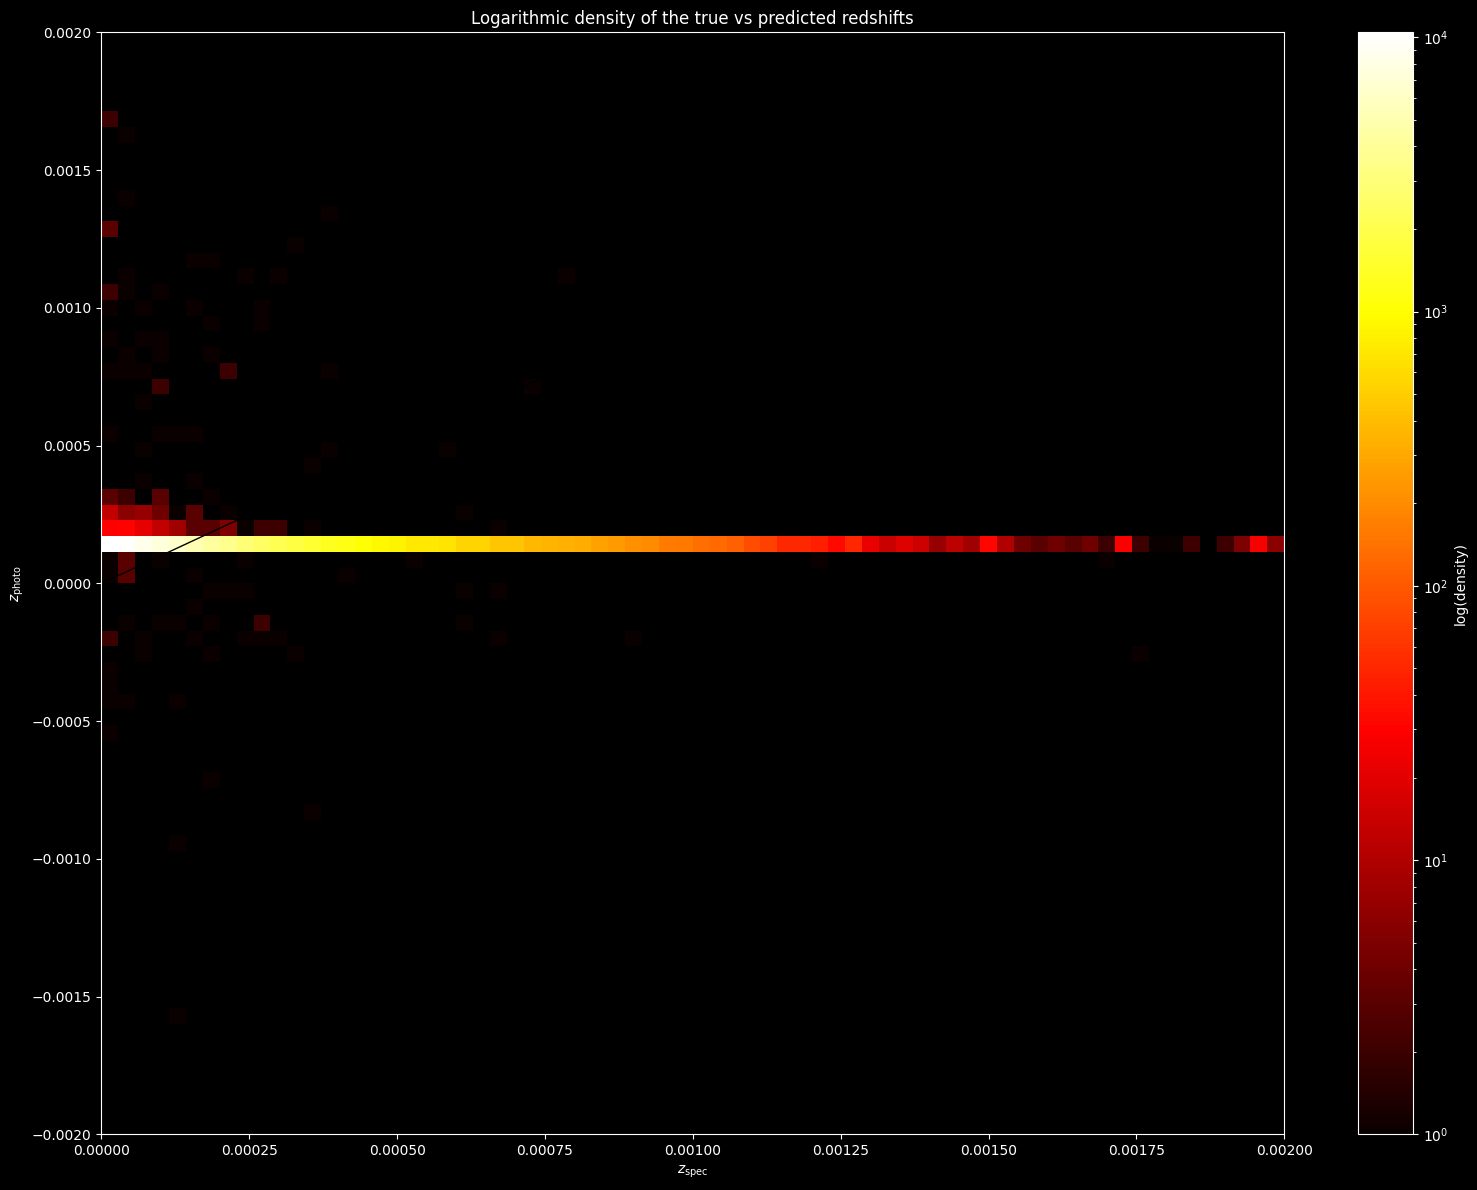

In [10]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATASETS USADOS HASTA AHORA

# Cargar checkpoint y estados del modelo
checkpoint = torch.load('storage/modelTRA_Stars.pth', map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])

all_preds = []
all_y = []
with torch.no_grad():
    # Evaluación en el conjunto de test
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        preds = modelTransformer(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())
    # Evaluación en el conjunto de train
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        preds = modelTransformer(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())

# Concatenar y convertir a vectores 1D (aplicando squeeze a ambos)
preds_all = np.concatenate(all_preds, axis=0).squeeze()
y_all = np.concatenate(all_y, axis=0).squeeze()

# Calcular la correlación lineal
corr = np.corrcoef(y_all, preds_all)[0, 1]
print(f"Correlación lineal: {corr:.4f}")

# Ajuste lineal: calcular pendiente (slope) e intercepto
slope, intercept = np.polyfit(y_all, preds_all, 1)
print("Slope:", slope)
print("Intercept:", intercept)

# Mapa de calor de z_real frente a z_predicho éstandar
plt.style.use('dark_background')
x_min, x_max = 0, 0.002
y_min, y_max = -0.002, 0.002
plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    y_all,                 # z_spec (redshift "real")
    preds_all,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)
cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

In [ ]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATOS COMPLETOS DE ESTRELLAS

import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [7]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class Transformer(nn.Module):
    def __init__(self, num_points, d_model=128, nhead=8, num_layers=4, dim_feedforward=256):
        super(Transformer, self).__init__()
        self.embedding = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(d_model),
            nn.MaxPool1d(kernel_size=2)
        )
        reduced_len = num_points // 16
        self.positional_encoding = PositionalEncoding(d_model, dropout=0.1, max_len=reduced_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc_layers = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x.transpose(1, 2)
        x = self.pooling(x).squeeze(-1)
        out = self.fc_layers(x)
        return out

num_points = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelTransformer = Transformer(num_points).to(device)

model_checkpoint = 'storage/modelTRA_Stars.pth'  # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelTransformer = Transformer(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelTransformer.load_state_dict(checkpoint['model_state_dict'])
modelTransformer.eval()

# Directorios y parámetros
data_dir  = "data"
storage_dir = "storage"
batch_size = 32

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        data = torch.load(dataset_path)
        self.flux = data["flux"]
        self.wavelength = data["wavelength"]
        self.redshift = data["redshift"]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target
    
    
data_dir = "data"
stars_dataset_path = os.path.join(data_dir, "stars_dataset.pt")
stars_dataset = SpectraDataset(stars_dataset_path)
batch_size = 32
stars_loader = DataLoader(stars_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

predicted = []
real = []

with torch.no_grad():
    for x_batch, y_batch in stars_loader:
        x_batch = x_batch.to(device)
        preds = modelTransformer(x_batch).cpu().numpy()  # forma: (batch_size, 1)
        predicted.append(preds)
        real.append(y_batch.numpy())

# Concatenar los resultados de la primera mitad
ypredicted = np.concatenate(predicted, axis=0)
yreal = np.concatenate(real, axis=0)

ypredicted = ypredicted.squeeze()     # Ahora tiene forma (N,)
yreal      = yreal.squeeze()          # Ahora tiene forma (N,)

Usando dispositivo: cuda


Correlación lineal: -0.0079
Número de muestras evaluadas: 329989


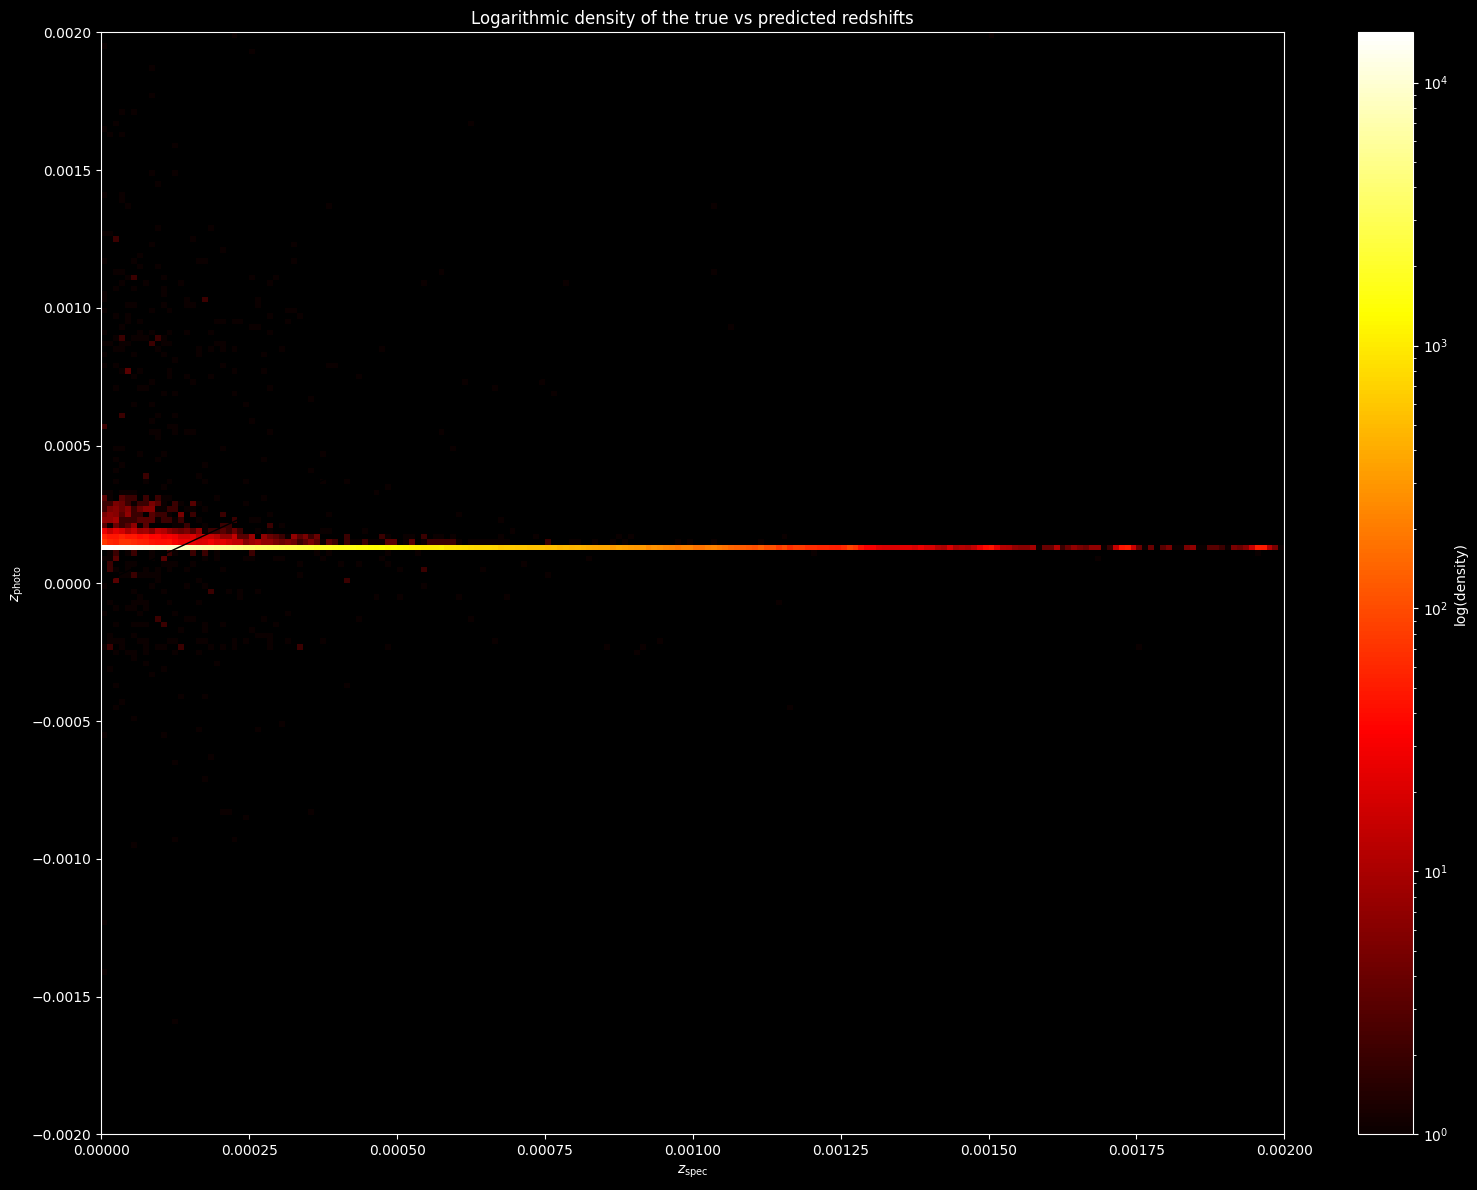

In [8]:
# Calcular la correlación lineal
correlation = np.corrcoef(yreal, ypredicted)[0, 1]

print(f"Correlación lineal: {correlation:.4f}")
print(f"Número de muestras evaluadas: {len(yreal)}")

# Mapa de calor de z_real frente a z_predicho estándar

plt.style.use('dark_background')

x_min, x_max = 0, 0.002
y_min, y_max = -0.002, 0.002

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=200,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()